In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dmax_df = pd.read_csv("dmax_df.csv")
dmean_df = pd.read_csv("dmean_df.csv")

features = [
    'ToothType', 'ExtractionFlag', 'TumorLaterality', 'TumorLocation',
    'TNM_T', 'TNM_N', 'TNM_Stage', 'Typetumor_cat',
    'Tumor_site', 'Stage', 'Systemic_therapy', 'StageItmIV'
]

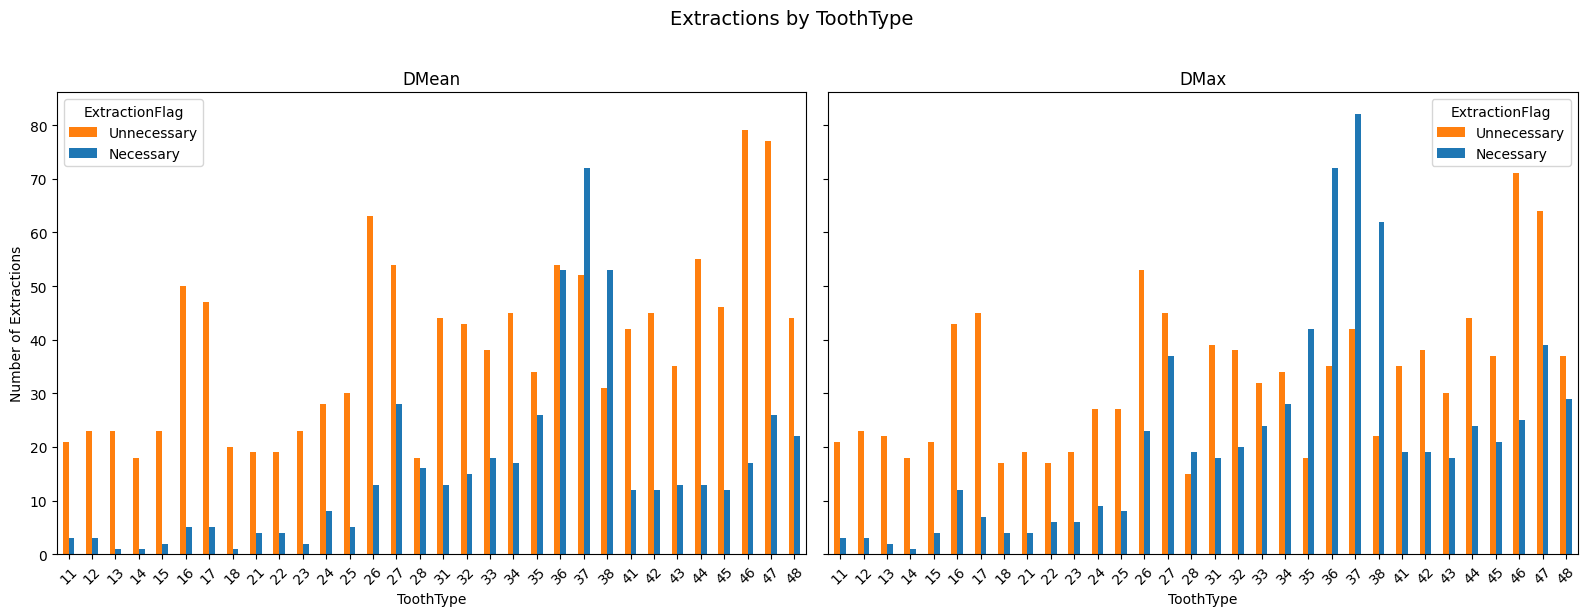

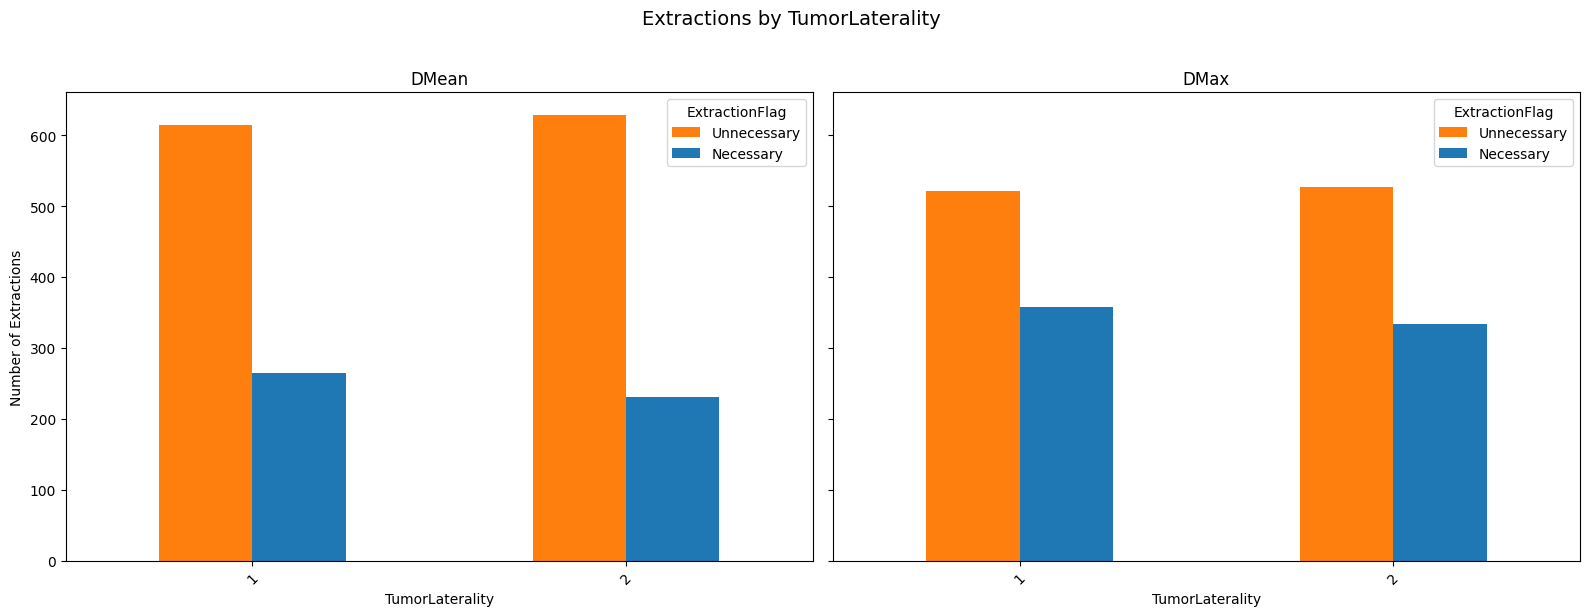

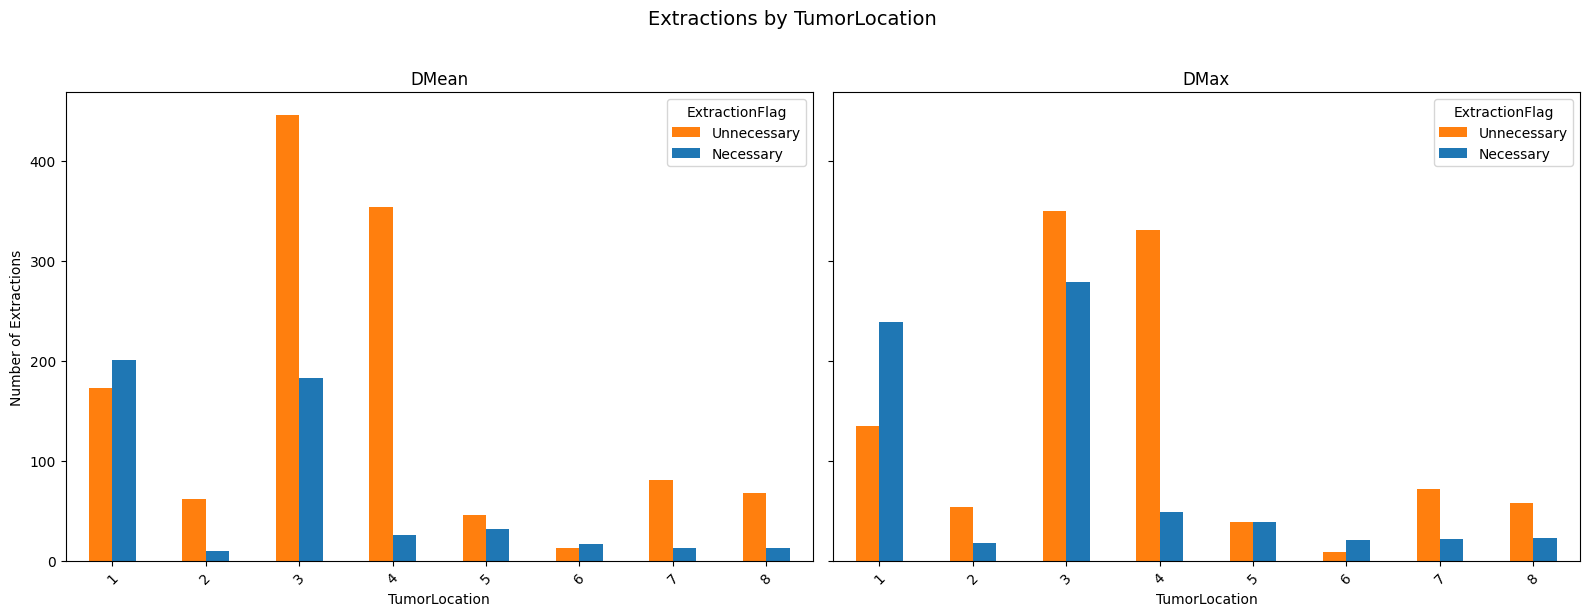

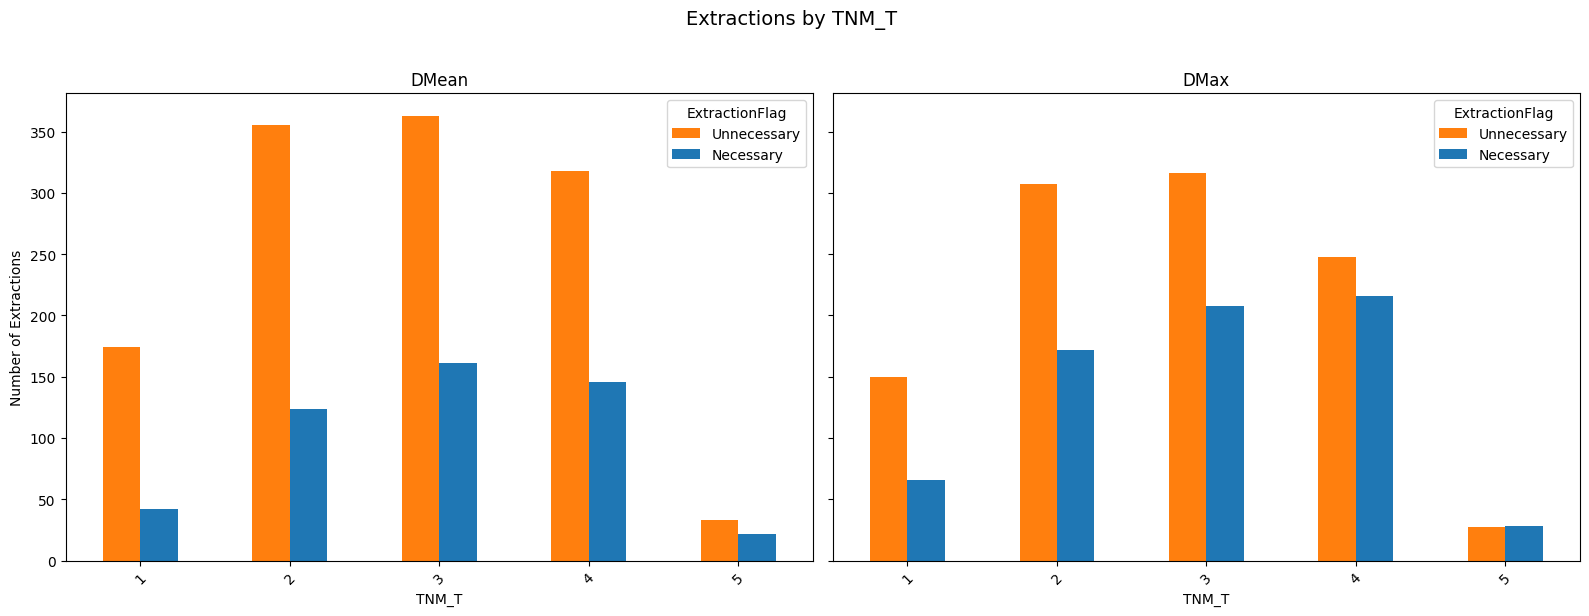

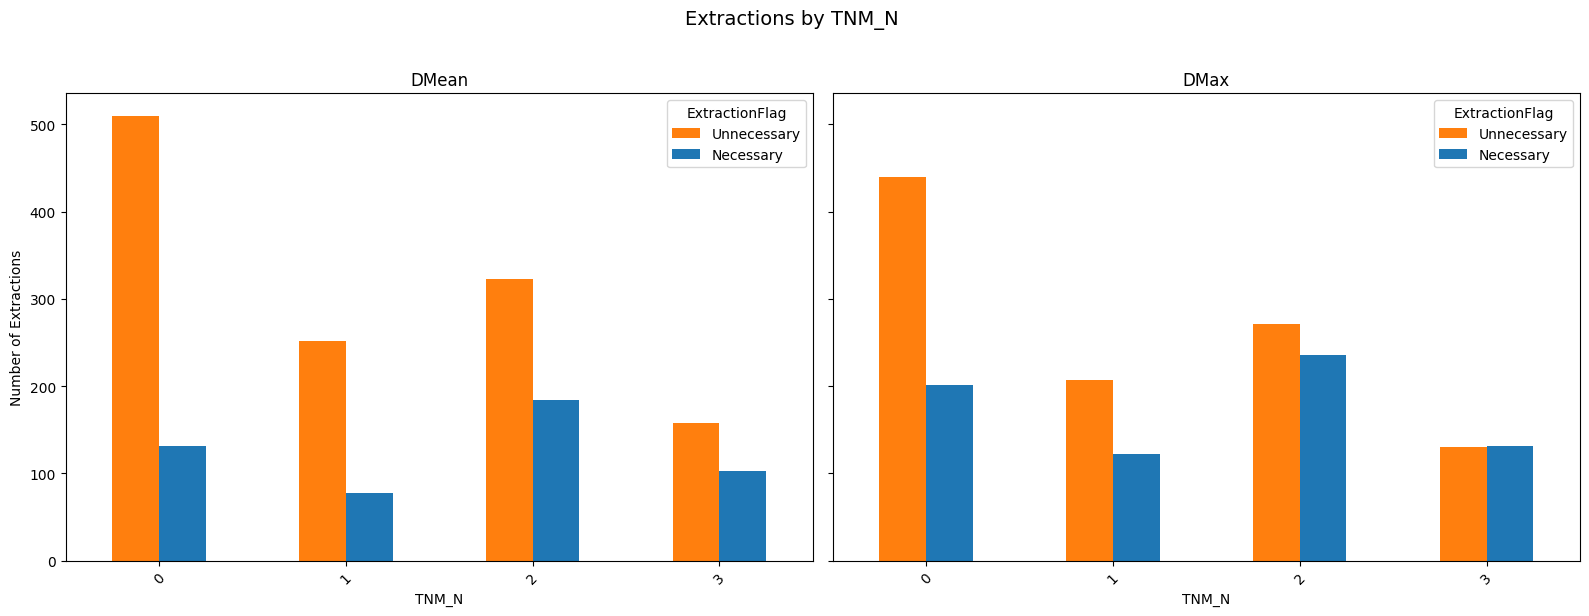

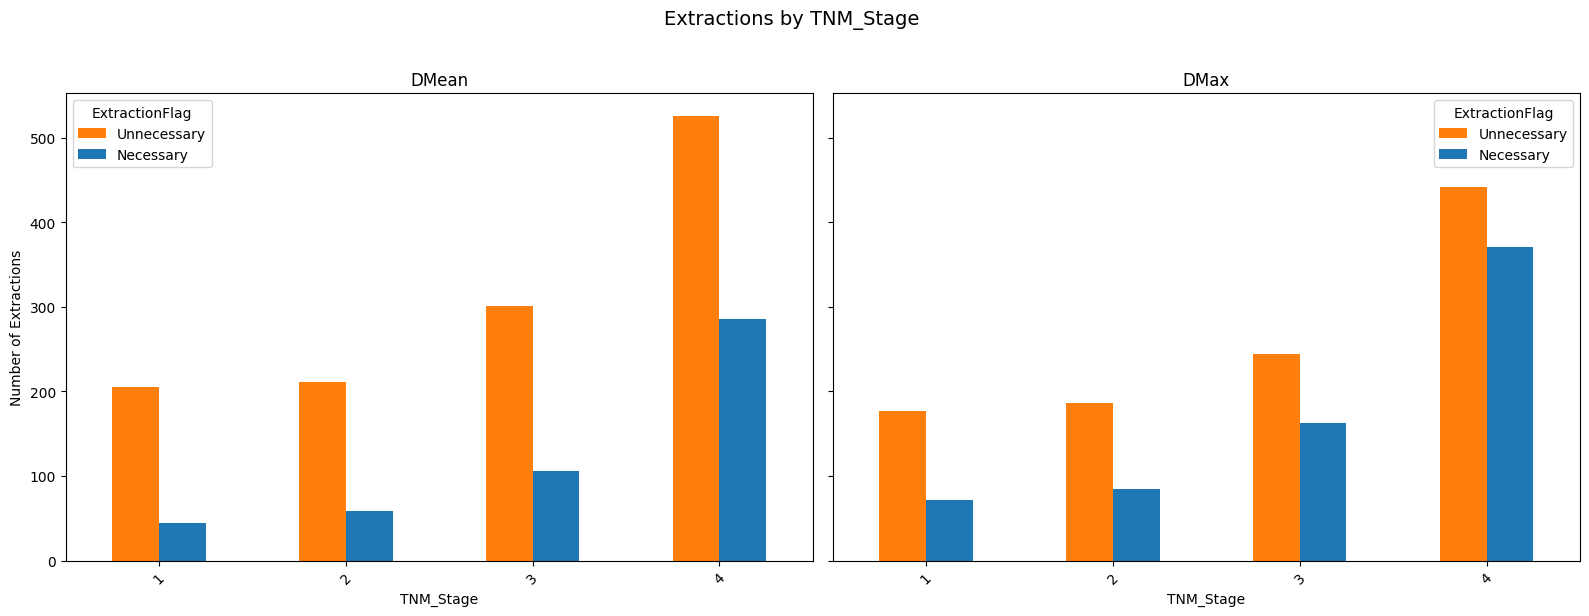

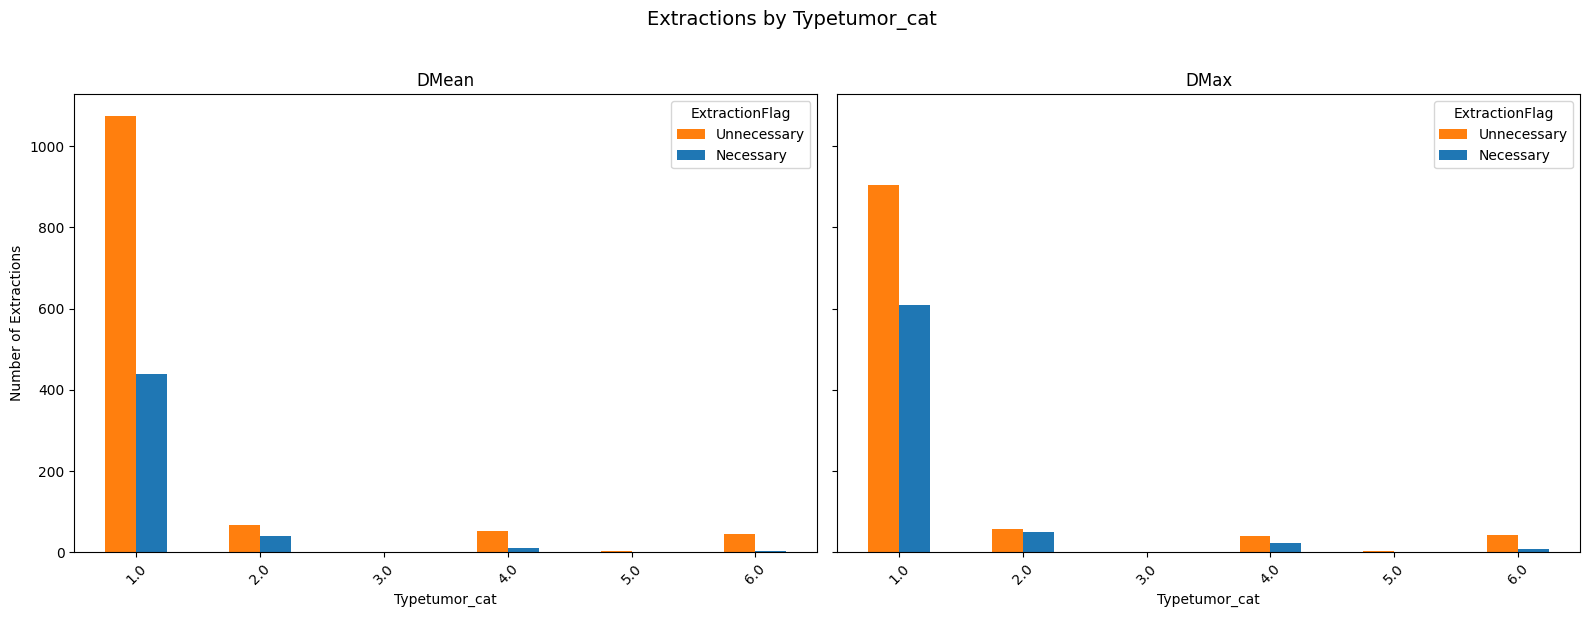

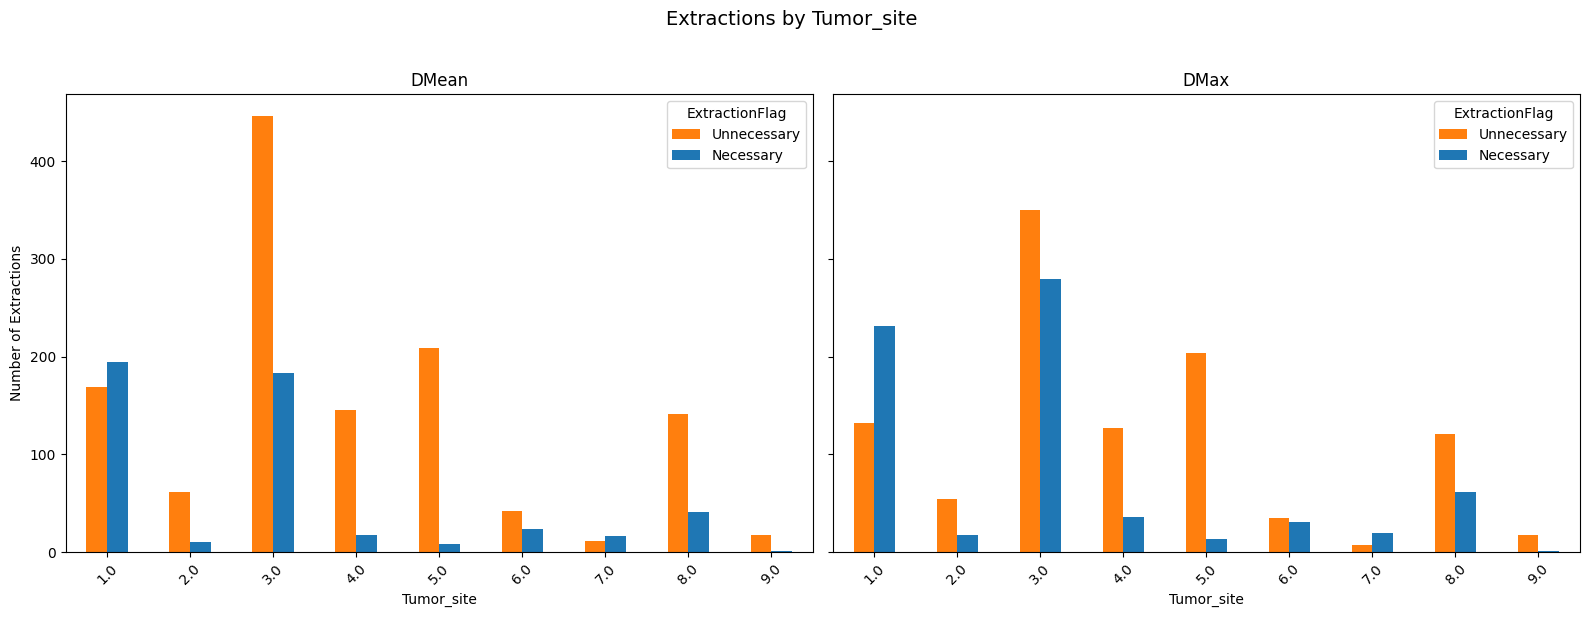

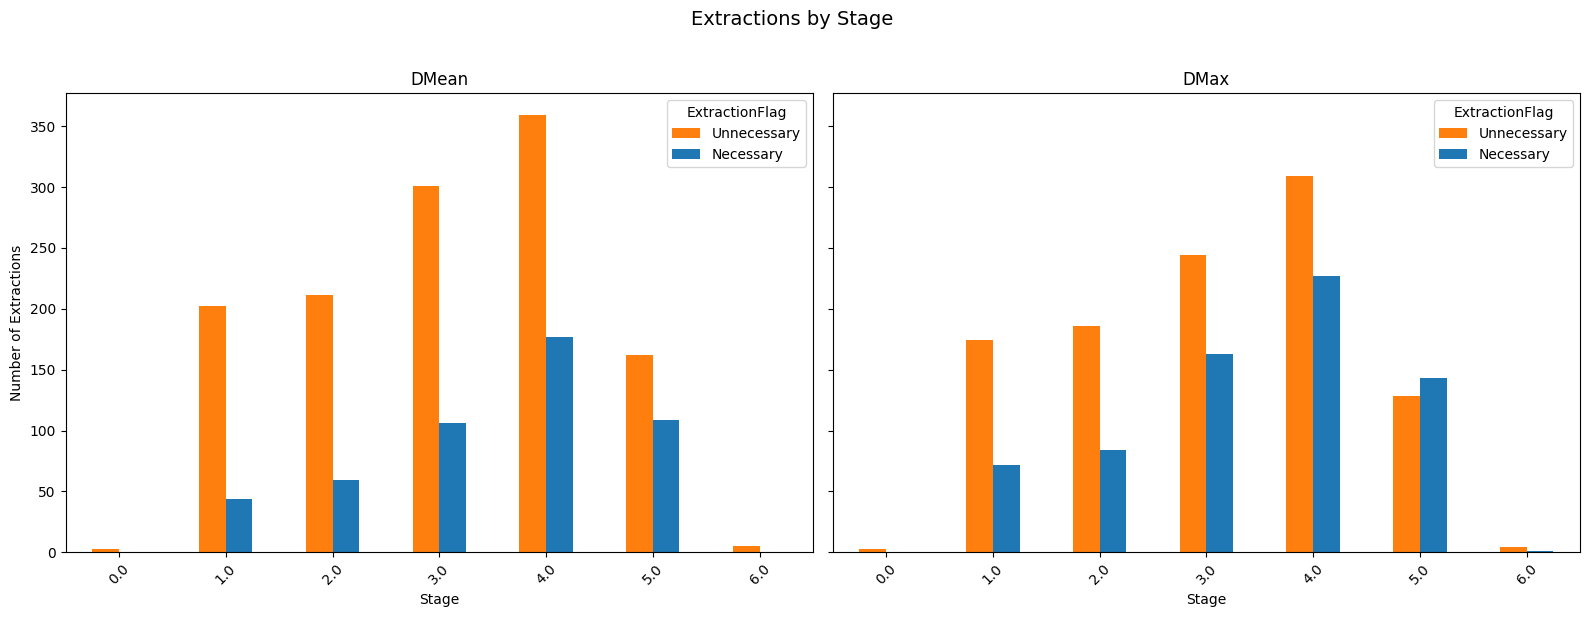

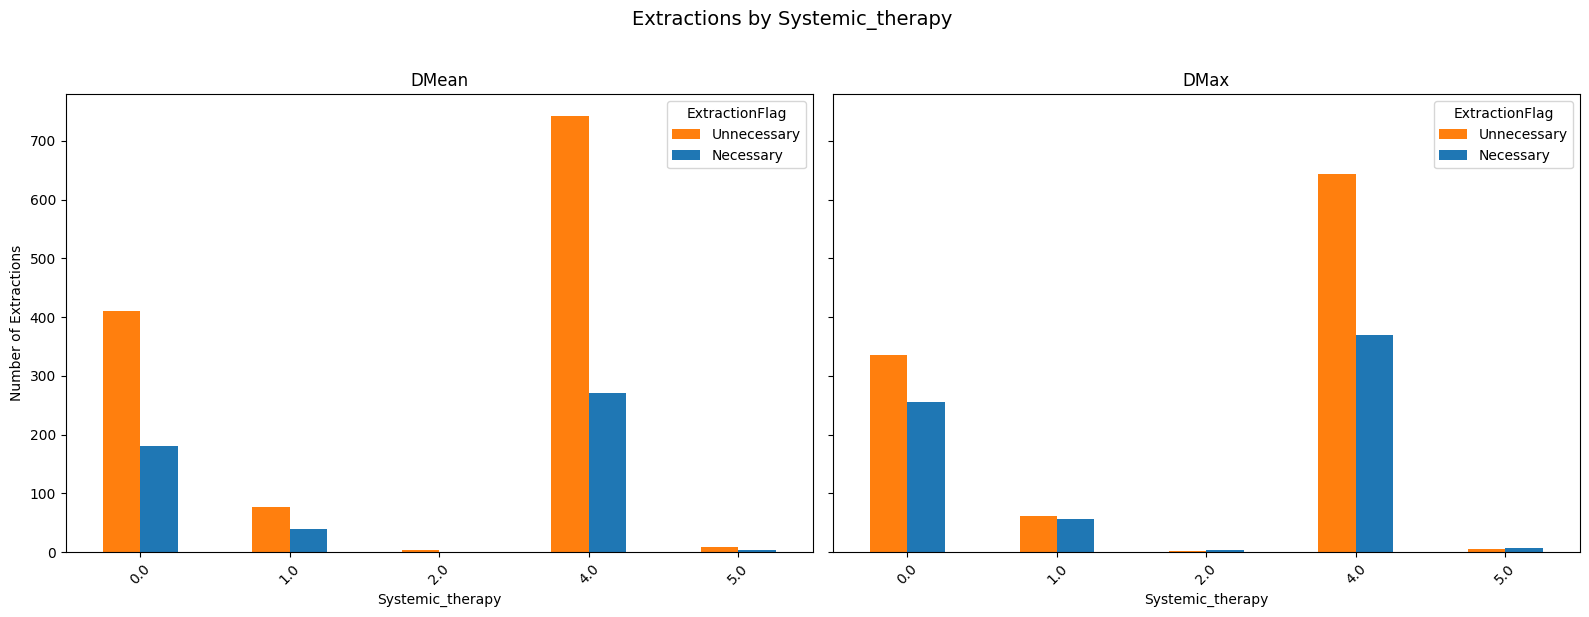

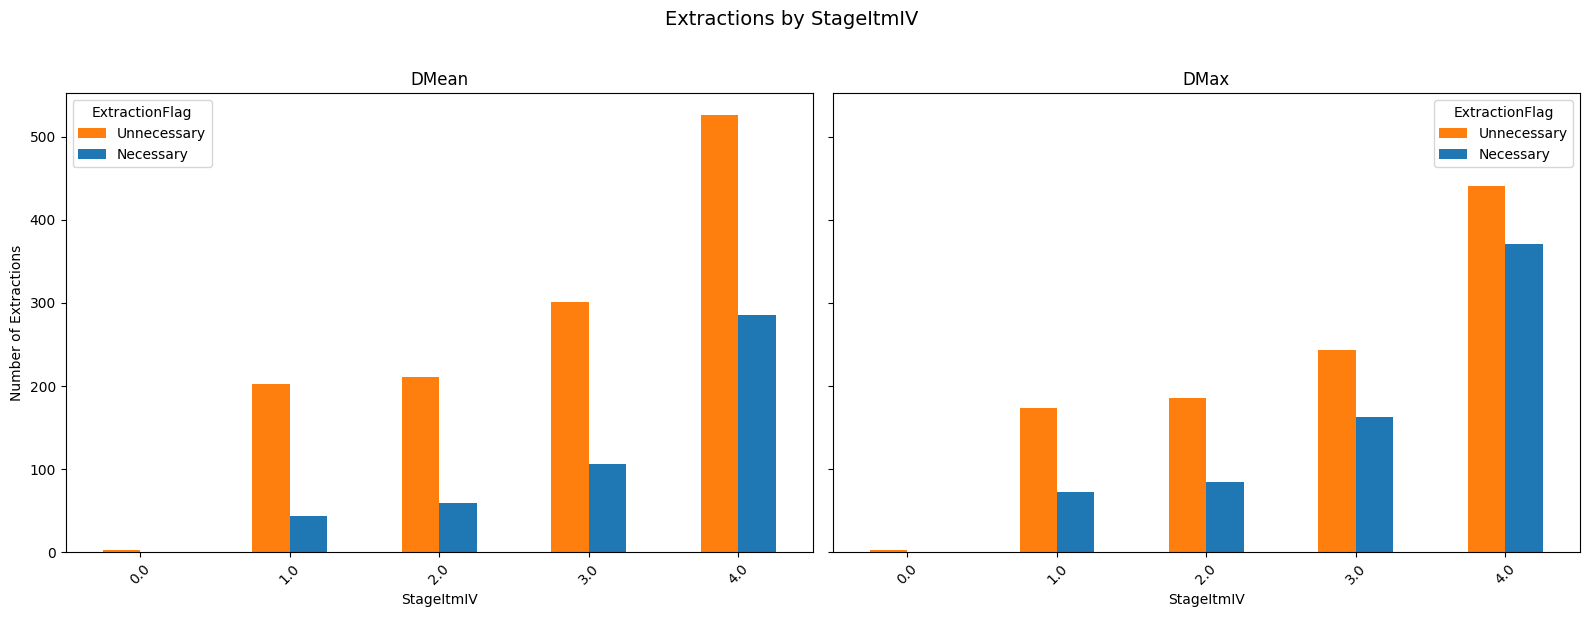

In [ ]:
split_flag = 'ExtractionFlag'
standard_colors = ['tab:orange', 'tab:blue']


# Ensure ExtractionFlag is 0/1 ints
for df in (dmax_df, dmean_df):
    if split_flag not in df.columns:
        raise ValueError(f"Missing '{split_flag}' in one of the dataframes.")
    df[split_flag] = pd.to_numeric(df[split_flag], errors='coerce').fillna(0).astype(int)
    df.loc[~df[split_flag].isin([0, 1]), split_flag] = 0

def plot_feature(col):
    if col == split_flag:
        return  

    if col not in dmean_df.columns or col not in dmax_df.columns:
        print(f"Skipping '{col}' (missing in one dataset).")
        return

    # Grouped counts
    mean_counts = dmean_df.groupby([col, split_flag]).size().unstack(fill_value=0)
    max_counts  = dmax_df.groupby([col, split_flag]).size().unstack(fill_value=0)

    # Ensure both flags present and in [0,1] order
    for c in (mean_counts, max_counts):
        for f in [0, 1]:
            if f not in c.columns:
                c[f] = 0
        c.sort_index(axis=1, inplace=True)
    mean_counts = mean_counts[[0, 1]]
    max_counts  = max_counts[[0, 1]]

    # frequency-based ordering
    total = (
        mean_counts.sum(axis=1).rename("mean_total").to_frame()
        .join(max_counts.sum(axis=1).rename("max_total"), how="outer")
        .fillna(0)
    )
    total["combined"] = total["mean_total"] + total["max_total"]
    union_idx = mean_counts.index.union(max_counts.index)
    order_vals = pd.to_numeric(union_idx.astype(str), errors='coerce')
    cat_order = [cat for _, cat in sorted(zip(order_vals, union_idx), key=lambda t: (t[0], str(t[1])))]

    mean_counts = mean_counts.reindex(cat_order).fillna(0)
    max_counts  = max_counts.reindex(cat_order).fillna(0)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    mean_counts.plot(kind='bar', color=standard_colors, ax=axes[0])
    axes[0].set_title("DMean")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Number of Extractions")
    axes[0].legend(["Unnecessary", "Necessary"], title="ExtractionFlag")
    axes[0].tick_params(axis='x', rotation=45)

    max_counts.plot(kind='bar', color=standard_colors, ax=axes[1])
    axes[1].set_title("DMax")
    axes[1].set_xlabel(col)
    axes[1].legend(["Unnecessary", "Necessary"], title="ExtractionFlag")
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle(f"Extractions by {col} ", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

for col in features:
    plot_feature(col)
